# Continuity Visualization

**Topic:** 03 — Continuity  
**Audience:** Machine Learning, Data Science, AI, Mathematics, and Engineering Students

---

This notebook provides a comprehensive, interactive, and visual exploration of **continuity** in calculus — with deep connections to **Machine Learning**, **Deep Learning**, and **Optimization**.

### Tools Used
- `NumPy` — numerical computation
- `Matplotlib` — static & animated visualizations
- `ipywidgets` — interactive sliders and controls
- `SymPy` — symbolic mathematics

> **Note:** Run `%matplotlib widget` in a Jupyter environment for interactive figures.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import FancyBboxPatch, Circle
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, fixed, VBox, HBox, Output
from IPython.display import display, HTML
import sympy as sp
from sympy import symbols, limit, sin, cos, exp, log, oo, latex, simplify, Rational


# Global style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 1. Introduction to Continuity

## Concept
A function is **continuous** if you can draw its graph without lifting your pen from the paper. Intuitively, there are no breaks, jumps, or holes in the curve.

## Mathematical Definition
A function $f(x)$ is **continuous at a point $x = a$** if and only if:

$$\lim_{x \to a} f(x) = f(a)$$

More explicitly, three conditions must hold:
1. $f(a)$ is defined
2. $\lim_{x \to a} f(x)$ exists
3. The limit equals the function value

## Intuition
Imagine walking along a smooth path. At no point do you need to teleport — you simply glide continuously from one point to the next. This is the essence of continuity.

## Real World Example
- The temperature of a room changes **continuously** over time.
- The speed of a car (ignoring gear shifts) changes continuously.

## AI/ML Connection
In machine learning, **loss functions** are typically designed to be continuous so that gradient-based optimization (like Gradient Descent) can smoothly navigate toward the minimum.

## Key Takeaway
> Continuity ensures predictability. In ML, it ensures that small changes in parameters lead to small changes in loss — making training stable.

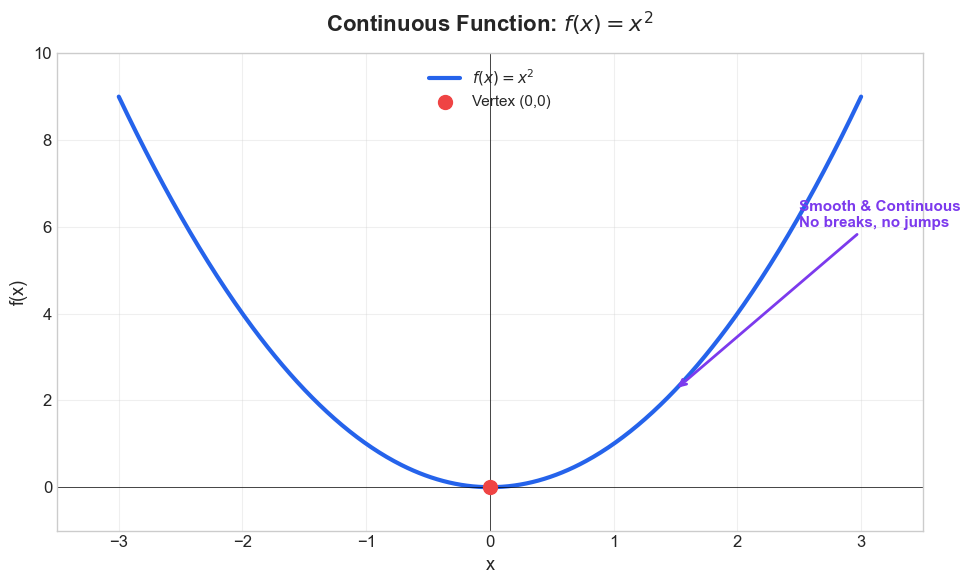

✅ Section 1 Complete: f(x) = x² is continuous everywhere on ℝ.


In [3]:
# Section 1: Visualizing f(x) = x^2 (Continuous Function)

x = np.linspace(-3, 3, 500)
y = x**2

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, color='#2563EB', linewidth=3, label=r'$f(x) = x^2$')
ax.scatter([0], [0], color='#EF4444', s=100, zorder=5, label='Vertex (0,0)')

ax.set_title('Continuous Function: $f(x) = x^2$', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.legend(loc='upper center', fontsize=11)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-1, 10)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# Add annotation
ax.annotate('Smooth & Continuous\nNo breaks, no jumps', 
            xy=(1.5, 2.25), xytext=(2.5, 6),
            arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=2),
            fontsize=11, color='#7C3AED', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Section 1 Complete: f(x) = x² is continuous everywhere on ℝ.")

# 2. Animated Continuity Demonstration

## Concept
An animation of a point moving along a continuous curve reinforces the idea that there are **no jumps**, **no breaks**, and **no holes**.

## Mathematical Definition
For a continuous function $f$ on interval $[a, b]$:

$$\forall x_0 \in [a,b], \quad \lim_{x \to x_0} f(x) = f(x_0)$$

## Intuition
Watch the red dot travel along the curve. It never skips, never jumps, and never falls into a hole. This is the visual signature of continuity.

## Real World Example
A satellite orbiting Earth follows a continuous trajectory. Its position is a continuous function of time.

## AI/ML Connection
During neural network training, the loss landscape is (ideally) continuous. The optimizer's path through parameter space should be smooth, not erratic.

## Key Takeaway
> Smooth motion along a curve = continuity. In optimization, smooth loss landscapes allow stable convergence.

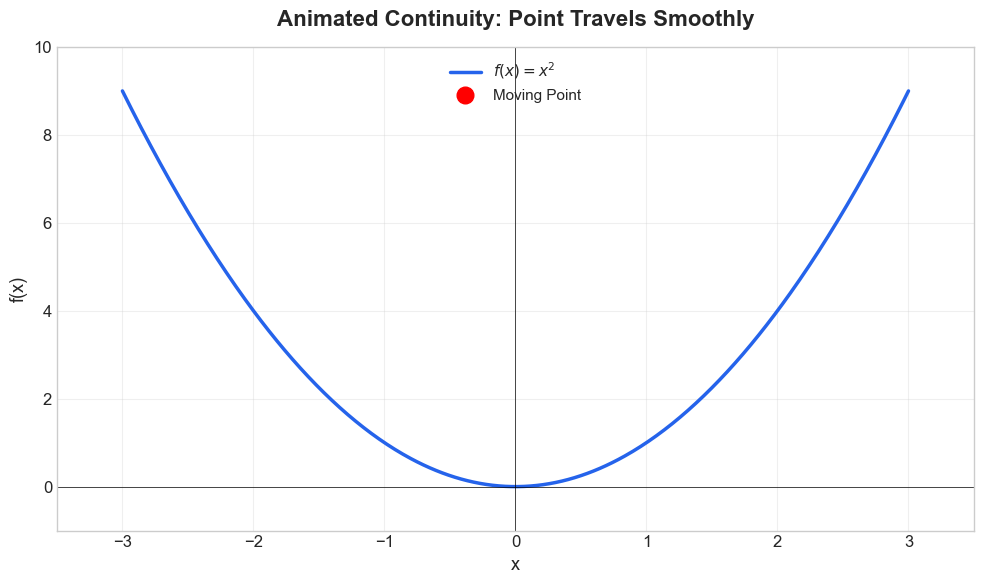

✅ Section 2 Complete: Animation shows smooth travel with no jumps.


In [4]:
# Section 2: Animated Point Moving Along Continuous Curve

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-3, 3, 500)
y = x**2

ax.plot(x, y, color='#2563EB', linewidth=2.5, label=r'$f(x) = x^2$')
point, = ax.plot([], [], 'ro', markersize=12, label='Moving Point')
trace, = ax.plot([], [], 'r--', alpha=0.5, linewidth=1.5)

ax.set_title('Animated Continuity: Point Travels Smoothly', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-1, 10)
ax.legend(loc='upper center', fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# Status text
status = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, 
                 verticalalignment='top', color='#059669', fontweight='bold')

def init():
    point.set_data([], [])
    trace.set_data([], [])
    status.set_text('')
    return point, trace, status

def update(frame):
    xi = x[frame]
    yi = y[frame]
    point.set_data([xi], [yi])
    trace.set_data(x[:frame+1], y[:frame+1])
    status.set_text(f'Position: ({xi:.2f}, {yi:.2f})  |  Status: ✅ Continuous')
    return point, trace, status

ani = FuncAnimation(fig, update, frames=len(x), init_func=init, 
                    interval=20, blit=True, repeat=True)

plt.tight_layout()
plt.show()

print("✅ Section 2 Complete: Animation shows smooth travel with no jumps.")

# 3. Left-Hand and Right-Hand Limit Visualizer

## Concept
To check continuity at a point, we examine the **left-hand limit** (approaching from below) and the **right-hand limit** (approaching from above).

## Mathematical Definition

**Left-Hand Limit:**
$$\lim_{x \to a^-} f(x) = L^-$$

**Right-Hand Limit:**
$$\lim_{x \to a^+} f(x) = L^+$$

For continuity at $x = a$:
$$\lim_{x \to a^-} f(x) = \lim_{x \to a^+} f(x) = f(a)$$

## Intuition
Imagine approaching a door from the left hallway and from the right hallway. If both paths lead to the same room, the transition is continuous.

## Real World Example
Checking if a bridge connects two roads smoothly — the elevation from both sides must match at the joint.

## AI/ML Connection
In piecewise activation functions (e.g., ReLU), we check left and right limits at the "kink" ($x = 0$) to understand differentiability and gradient behavior.

## Key Takeaway
> Left and right limits must agree for continuity. In ML, this ensures gradients are well-defined from both sides of a decision boundary.

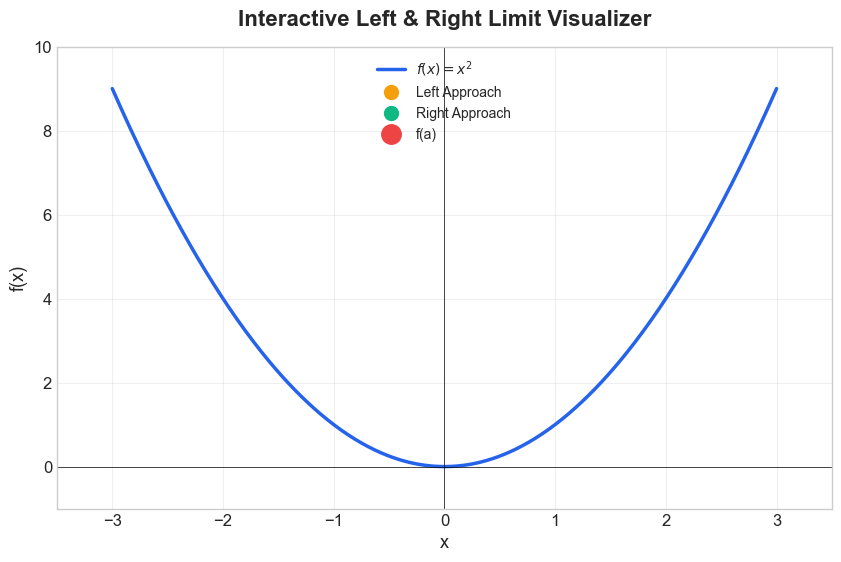

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Point a:', max=2.5, min=-2.…

✅ Section 3 Complete: Use the slider to explore left & right limits.


In [5]:
# Section 3: Interactive Left & Right Limit Visualizer

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-3, 3, 500)
y = x**2

line, = ax.plot(x, y, color='#2563EB', linewidth=2.5, label=r'$f(x) = x^2$')
left_dot, = ax.plot([], [], 'o', color='#F59E0B', markersize=10, label='Left Approach')
right_dot, = ax.plot([], [], 'o', color='#10B981', markersize=10, label='Right Approach')
center_dot, = ax.plot([], [], 'o', color='#EF4444', markersize=14, label='f(a)')

ax.set_title('Interactive Left & Right Limit Visualizer', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-1, 10)
ax.legend(loc='upper center', fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

info_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=11, 
                    verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9))

def update_limits(a):
    ax.clear()
    ax.plot(x, y, color='#2563EB', linewidth=2.5, label=r'$f(x) = x^2$')

    # Left approach
    left_x = np.linspace(a - 0.5, a, 50)
    left_y = left_x**2
    ax.plot(left_x, left_y, '--', color='#F59E0B', linewidth=2, alpha=0.7)
    ax.plot([a - 0.05], [(a - 0.05)**2], 'o', color='#F59E0B', markersize=10, label='Left Approach')

    # Right approach
    right_x = np.linspace(a, a + 0.5, 50)
    right_y = right_x**2
    ax.plot(right_x, right_y, '--', color='#10B981', linewidth=2, alpha=0.7)
    ax.plot([a + 0.05], [(a + 0.05)**2], 'o', color='#10B981', markersize=10, label='Right Approach')

    # Center point
    ax.plot([a], [a**2], 'o', color='#EF4444', markersize=14, label='f(a)')
    ax.axvline(a, color='gray', linestyle=':', alpha=0.5)

    ax.set_title(f'Limits at a = {a:.2f}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('f(x)', fontsize=13)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1, 10)
    ax.legend(loc='upper center', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

    # Info box
    lim_left = a**2
    lim_right = a**2
    fa = a**2
    status = "✅ CONTINUOUS" if abs(lim_left - lim_right) < 1e-10 and abs(lim_left - fa) < 1e-10 else "❌ DISCONTINUOUS"

    ax.text(0.02, 0.95, 
            f'a = {a:.3f}\n'
            f'lim(x→a⁻) = {lim_left:.4f}\n'
            f'lim(x→a⁺) = {lim_right:.4f}\n'
            f'f(a) = {fa:.4f}\n'
            f'{status}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.95))

    plt.draw()

interact(update_limits, a=FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.0, 
                                       description='Point a:', continuous_update=False));

print("✅ Section 3 Complete: Use the slider to explore left & right limits.")

# 4. Removable Discontinuity Visualization

## Concept
A **removable discontinuity** occurs when a function has a "hole" at a point — the limit exists, but the function is either undefined or has a different value at that point.

## Mathematical Definition

Consider:
$$f(x) = \frac{x^2 - 1}{x - 1}$$

For $x \neq 1$:
$$f(x) = \frac{(x-1)(x+1)}{x-1} = x + 1$$

At $x = 1$:
- $f(1)$ is **undefined** (0/0 form)
- But $\lim_{x \to 1} f(x) = 2$

## Intuition
It's like a single missing brick in a perfectly built wall. The wall is almost complete — you just need to fill that one gap.

## Real World Example
A heart monitor that briefly loses signal for one millisecond. The underlying signal is continuous; we just need to "fill in" the missing data point.

## AI/ML Connection
In data preprocessing, missing values in a dataset can be thought of as "removable discontinuities." Interpolation techniques (like mean imputation) "remove" these discontinuities.

## Key Takeaway
> Removable discontinuities are "fixable." In ML, missing data points can often be imputed to restore continuity.

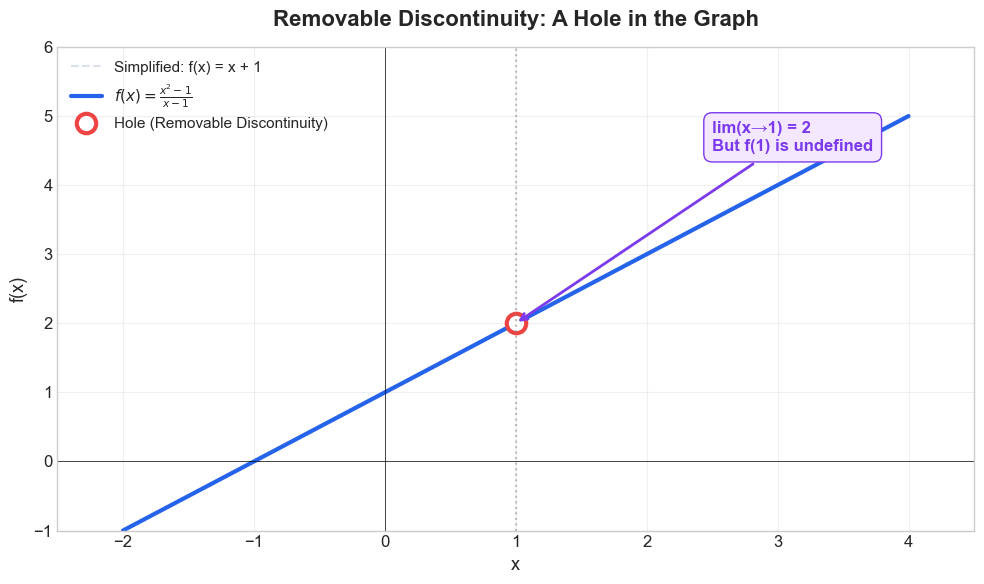

✅ Section 4 Complete: Removable discontinuity at x = 1.


In [6]:
# Section 4: Removable Discontinuity

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-2, 4, 500)
x_hole = 1.0

# Full line (what the function "wants" to be)
x_full = np.linspace(-2, 4, 500)
y_full = x_full + 1

# Actual function (with hole)
x_left = x[x < x_hole - 0.02]
x_right = x[x > x_hole + 0.02]
y_left = (x_left**2 - 1) / (x_left - 1)
y_right = (x_right**2 - 1) / (x_right - 1)

# Plot the continuous "intended" line lightly
ax.plot(x_full, y_full, '--', color='#CBD5E1', linewidth=1.5, alpha=0.7, label='Simplified: f(x) = x + 1')

# Plot actual function with hole
ax.plot(x_left, y_left, color='#2563EB', linewidth=3, label=r'$f(x) = \frac{x^2 - 1}{x - 1}$')
ax.plot(x_right, y_right, color='#2563EB', linewidth=3)

# Hole (open circle)
ax.plot(x_hole, x_hole + 1, 'o', color='#EF4444', markersize=14, 
        markerfacecolor='white', markeredgewidth=3, label='Hole (Removable Discontinuity)')

# Limit annotation
ax.annotate(f'lim(x→1) = 2\nBut f(1) is undefined', 
            xy=(1, 2), xytext=(2.5, 4.5),
            arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=2),
            fontsize=12, color='#7C3AED', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F3E8FF', edgecolor='#7C3AED'))

ax.set_title('Removable Discontinuity: A Hole in the Graph', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-2.5, 4.5)
ax.set_ylim(-1, 6)
ax.legend(loc='upper left', fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(1, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Section 4 Complete: Removable discontinuity at x = 1.")

# 5. Jump Discontinuity Visualization

## Concept
A **jump discontinuity** occurs when the left-hand and right-hand limits exist but are **not equal**. The function "jumps" from one value to another.

## Mathematical Definition

$$f(x) = \begin{cases} 1 & \text{if } x < 0 \\ 2 & \text{if } x \geq 0 \end{cases}$$

At $x = 0$:
- $\lim_{x \to 0^-} f(x) = 1$
- $\lim_{x \to 0^+} f(x) = 2$
- $f(0) = 2$

Since $L^- \neq L^+$, the function has a **jump discontinuity** at $x = 0$.

## Intuition
Imagine stepping off a curb. Your elevation changes instantaneously — that's a jump.

## Real World Example
- A light switch: OFF (0) to ON (1) is a jump discontinuity in power output.
- Stock prices at market open can exhibit jump behavior.

## AI/ML Connection
- **Step functions** in early perceptrons caused jump discontinuities.
- Modern neural networks use smooth approximations (sigmoid, tanh) to avoid jumps, enabling gradient-based learning.

## Key Takeaway
> Jump discontinuities break gradients. In deep learning, we prefer smooth activations to avoid sudden, unpredictable changes in loss.

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\2742448177.py:43: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
e:\Organization\ML-Verse\mlverse-machine-learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


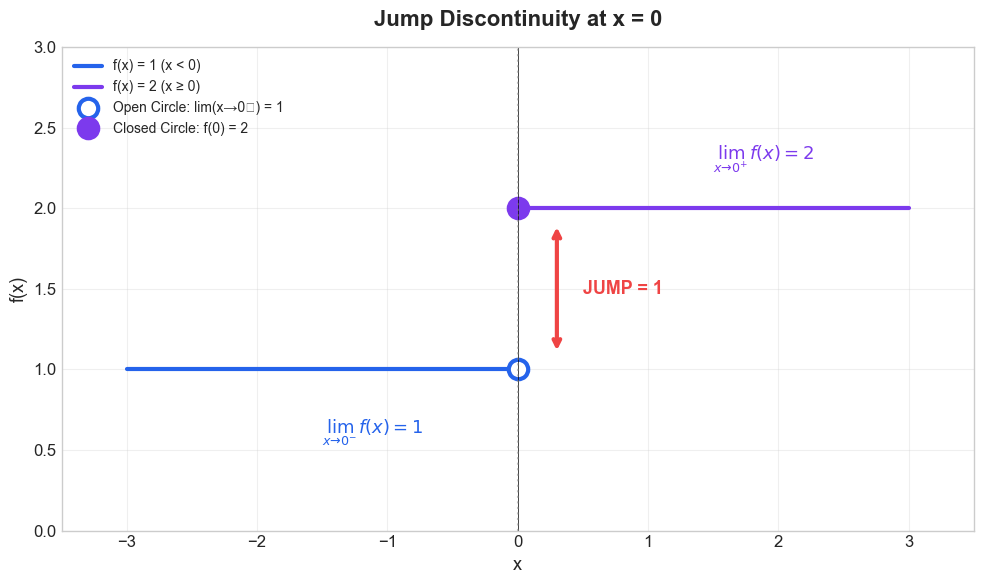

✅ Section 5 Complete: Jump discontinuity — left limit ≠ right limit.


In [7]:
# Section 5: Jump Discontinuity

fig, ax = plt.subplots(figsize=(10, 6))

x_left = np.linspace(-3, -0.01, 200)
x_right = np.linspace(0, 3, 200)

y_left = np.ones_like(x_left)
y_right = 2 * np.ones_like(x_right)

# Plot left branch
ax.plot(x_left, y_left, color='#2563EB', linewidth=3, label='f(x) = 1 (x < 0)')
# Plot right branch
ax.plot(x_right, y_right, color='#7C3AED', linewidth=3, label='f(x) = 2 (x ≥ 0)')

# Open circle at (0, 1) — limit from left
ax.plot(0, 1, 'o', color='#2563EB', markersize=14, 
        markerfacecolor='white', markeredgewidth=3, label='Open Circle: lim(x→0⁻) = 1')

# Closed circle at (0, 2) — function value
ax.plot(0, 2, 'o', color='#7C3AED', markersize=14, 
        markerfacecolor='#7C3AED', markeredgewidth=3, label='Closed Circle: f(0) = 2')

# Jump arrow
ax.annotate('', xy=(0.3, 1.9), xytext=(0.3, 1.1),
            arrowprops=dict(arrowstyle='<->', color='#EF4444', lw=3))
ax.text(0.5, 1.5, 'JUMP = 1', fontsize=13, color='#EF4444', fontweight='bold', va='center')

# Limit annotations
ax.text(-1.5, 0.6, r'$\lim_{x \to 0^-} f(x) = 1$', fontsize=13, color='#2563EB', fontweight='bold')
ax.text(1.5, 2.3, r'$\lim_{x \to 0^+} f(x) = 2$', fontsize=13, color='#7C3AED', fontweight='bold')

ax.set_title('Jump Discontinuity at x = 0', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(0, 3)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Section 5 Complete: Jump discontinuity — left limit ≠ right limit.")

# 6. Infinite Discontinuity Visualization

## Concept
An **infinite discontinuity** occurs when a function grows without bound (toward $+\infty$ or $-\infty$) as $x$ approaches a point. This creates a **vertical asymptote**.

## Mathematical Definition

$$f(x) = \frac{1}{x}$$

At $x = 0$:
- $\lim_{x \to 0^+} \frac{1}{x} = +\infty$
- $\lim_{x \to 0^-} \frac{1}{x} = -\infty$
- $f(0)$ is **undefined**

## Intuition
Imagine approaching a black hole. As you get closer, the gravitational pull (and your speed) increases without bound — you never actually reach the center in finite time.

## Real World Example
- Electrical resistance approaches infinity as a wire's cross-section approaches zero.
- The force between two charged particles approaches infinity as distance approaches zero.

## AI/ML Connection
- **Division by zero** in loss computations (e.g., when a probability becomes exactly 0 in log-loss) causes infinite discontinuities.
- This is why we add small epsilon values ($10^{-7}$) to prevent numerical instability.

## Key Takeaway
> Infinite discontinuities are catastrophic in computation. In ML, we use numerical safeguards (clipping, epsilon) to avoid them.

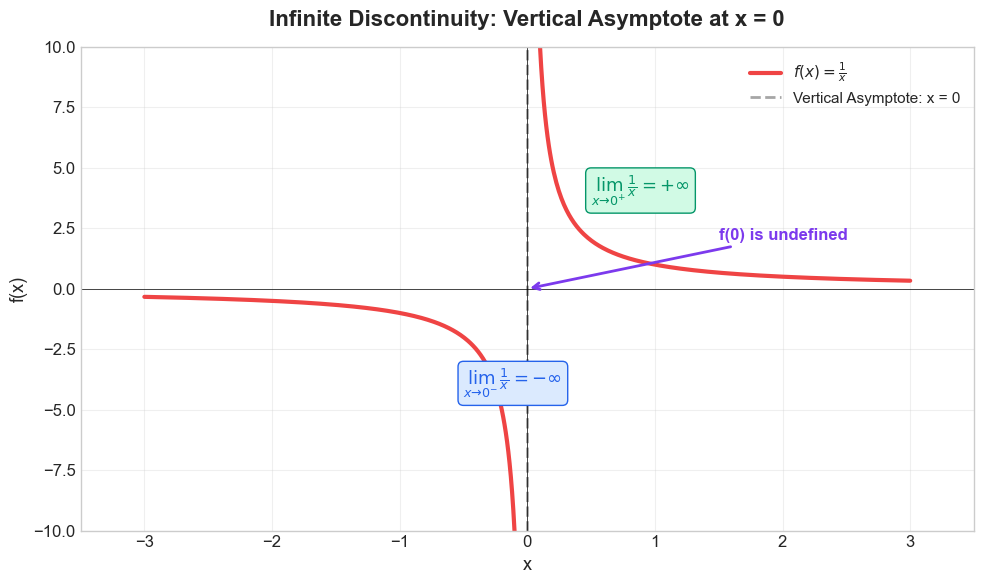

✅ Section 6 Complete: Infinite discontinuity with vertical asymptote.


In [8]:
# Section 6: Infinite Discontinuity

fig, ax = plt.subplots(figsize=(10, 6))

x_left = np.linspace(-3, -0.05, 300)
x_right = np.linspace(0.05, 3, 300)

y_left = 1 / x_left
y_right = 1 / x_right

# Plot branches
ax.plot(x_left, y_left, color='#EF4444', linewidth=3, label=r'$f(x) = \frac{1}{x}$')
ax.plot(x_right, y_right, color='#EF4444', linewidth=3)

# Vertical asymptote
ax.axvline(0, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Vertical Asymptote: x = 0')

# Annotations
ax.annotate(r'$\lim_{x \to 0^-} \frac{1}{x} = -\infty$', 
            xy=(-0.5, -4), fontsize=13, color='#2563EB', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#DBEAFE', edgecolor='#2563EB'))

ax.annotate(r'$\lim_{x \to 0^+} \frac{1}{x} = +\infty$', 
            xy=(0.5, 4), fontsize=13, color='#059669', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#D1FAE5', edgecolor='#059669'))

ax.annotate('f(0) is undefined', xy=(0, 0), xytext=(1.5, 2),
            arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=2),
            fontsize=12, color='#7C3AED', fontweight='bold')

ax.set_title('Infinite Discontinuity: Vertical Asymptote at x = 0', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-10, 10)
ax.legend(loc='upper right', fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("✅ Section 6 Complete: Infinite discontinuity with vertical asymptote.")

# 7. Oscillatory Discontinuity Visualization

## Concept
An **oscillatory discontinuity** occurs when a function oscillates infinitely rapidly as it approaches a point, so the limit does not exist.

## Mathematical Definition

$$f(x) = \sin\left(\frac{1}{x}\right)$$

As $x \to 0$:
- The argument $\frac{1}{x} \to \pm\infty$
- $\sin(\frac{1}{x})$ oscillates between $-1$ and $1$ **infinitely often**
- The limit **does not exist**

## Intuition
Imagine a bell that rings faster and faster as you approach it, until it's ringing infinitely fast. You can't pin down a single "sound" at the center.

## Real World Example
- Mechanical resonance near a natural frequency can exhibit oscillatory behavior.
- Quantum mechanical wave functions near singular potentials.

## AI/ML Connection
- **High-frequency noise** in signals can create oscillatory behavior.
- **Adversarial perturbations** can cause models to oscillate wildly in prediction space near decision boundaries.

## Key Takeaway
> Oscillatory discontinuities are pathological. In ML, high-frequency noise must be filtered (smoothed) to ensure stable learning.

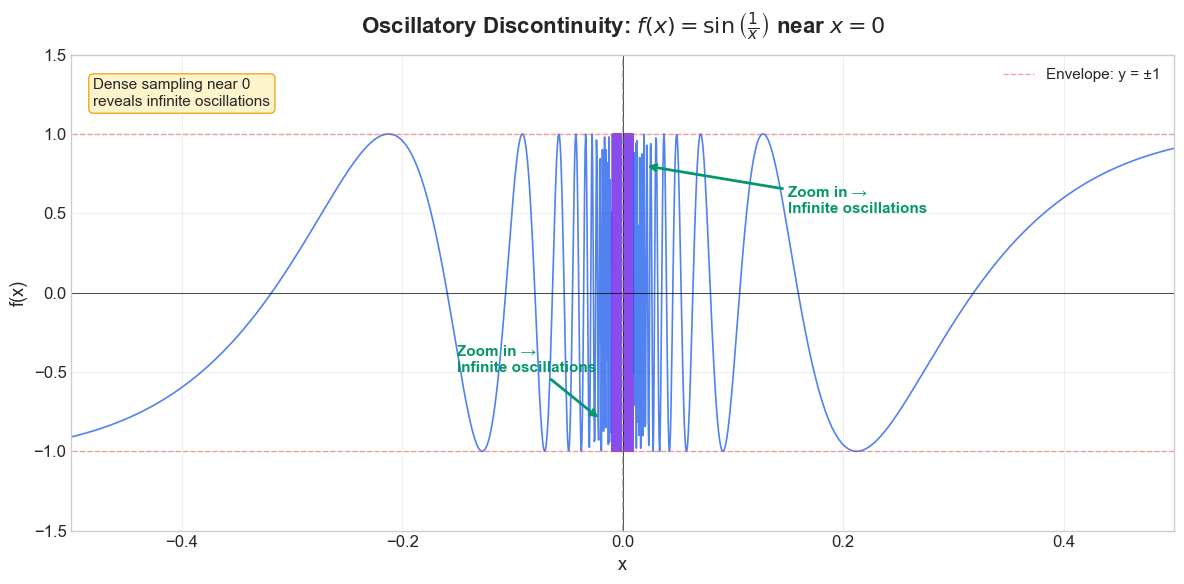

✅ Section 7 Complete: Oscillatory discontinuity — limit DNE at x = 0.


In [9]:
# Section 7: Oscillatory Discontinuity

fig, ax = plt.subplots(figsize=(12, 6))

# Dense sampling near zero
x_outer = np.linspace(-0.5, -0.01, 1000)
x_inner_neg = np.linspace(-0.01, -0.001, 5000)
x_inner_pos = np.linspace(0.001, 0.01, 5000)
x_outer_pos = np.linspace(0.01, 0.5, 1000)

y_outer = np.sin(1 / x_outer)
y_inner_neg = np.sin(1 / x_inner_neg)
y_inner_pos = np.sin(1 / x_inner_pos)
y_outer_pos = np.sin(1 / x_outer_pos)

# Plot all segments
ax.plot(x_outer, y_outer, color='#2563EB', linewidth=1.2, alpha=0.8)
ax.plot(x_inner_neg, y_inner_neg, color='#7C3AED', linewidth=0.8, alpha=0.9)
ax.plot(x_inner_pos, y_inner_pos, color='#7C3AED', linewidth=0.8, alpha=0.9)
ax.plot(x_outer_pos, y_outer_pos, color='#2563EB', linewidth=1.2, alpha=0.8)

# Envelope lines
x_env = np.linspace(0.001, 0.5, 1000)
ax.plot(x_env, np.ones_like(x_env), '--', color='#EF4444', alpha=0.5, linewidth=1, label='Envelope: y = ±1')
ax.plot(x_env, -np.ones_like(x_env), '--', color='#EF4444', alpha=0.5, linewidth=1)
ax.plot(-x_env, np.ones_like(x_env), '--', color='#EF4444', alpha=0.5, linewidth=1)
ax.plot(-x_env, -np.ones_like(x_env), '--', color='#EF4444', alpha=0.5, linewidth=1)

# Zoom inset indicator
ax.annotate('Zoom in →\nInfinite oscillations', xy=(0.02, 0.8), xytext=(0.15, 0.5),
            arrowprops=dict(arrowstyle='->', color='#059669', lw=2),
            fontsize=11, color='#059669', fontweight='bold')

ax.annotate('Zoom in →\nInfinite oscillations', xy=(-0.02, -0.8), xytext=(-0.15, -0.5),
            arrowprops=dict(arrowstyle='->', color='#059669', lw=2),
            fontsize=11, color='#059669', fontweight='bold')

ax.set_title(r'Oscillatory Discontinuity: $f(x) = \sin\left(\frac{1}{x}\right)$ near $x = 0$', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.legend(loc='upper right', fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='x = 0')

# Add density annotation
ax.text(0.02, 0.95, 'Dense sampling near 0\nreveals infinite oscillations', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#FEF3C7', edgecolor='#F59E0B', alpha=0.9))

plt.tight_layout()
plt.show()

print("✅ Section 7 Complete: Oscillatory discontinuity — limit DNE at x = 0.")

# 8. Interactive Continuity Checker

## Concept
Build an interactive tool that lets you select any point $a$ on a function and instantly checks whether the function is continuous at that point.

## Mathematical Definition
For a chosen point $a$:
1. Compute $f(a)$
2. Compute $\lim_{x \to a^-} f(x)$
3. Compute $\lim_{x \to a^+} f(x)$
4. Check if all three are equal

## Intuition
This is like a diagnostic tool for functions — a "continuity stethoscope" that listens for breaks, jumps, and holes.

## Real World Example
Quality control in manufacturing: scanning a product surface for cracks or gaps.

## AI/ML Connection
In automated ML pipelines, we need to verify that loss functions and metrics are continuous across the parameter space to ensure reliable training.

## Key Takeaway
> Automated continuity checking is essential for validating ML models and ensuring optimization landscapes are well-behaved.

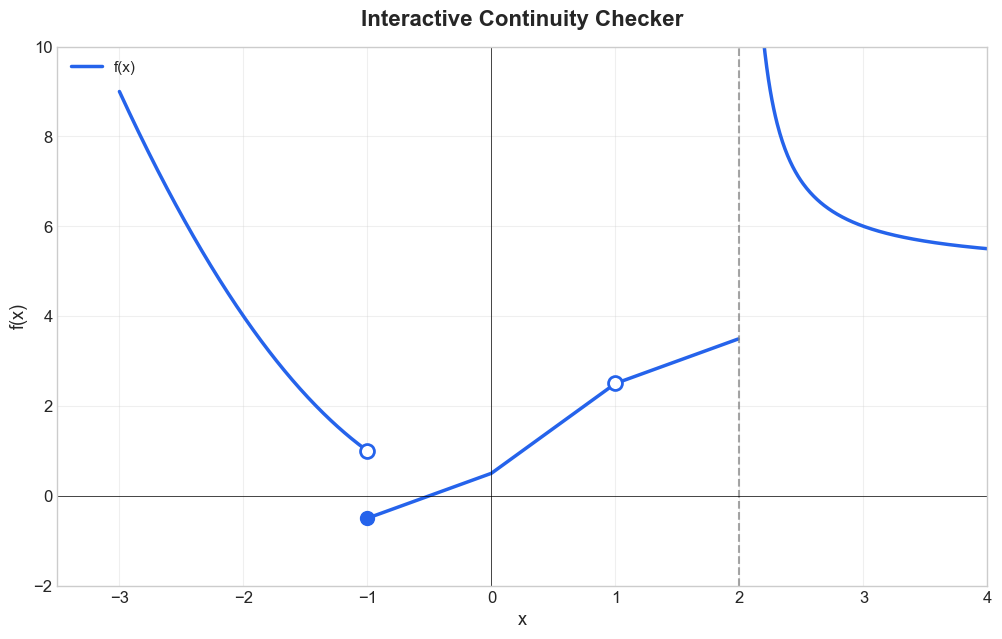

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Point a:', max=3.5, min=-3.…

✅ Section 8 Complete: Interactive continuity checker with multiple discontinuity types.


In [10]:
# Section 8: Interactive Continuity Checker

fig, ax = plt.subplots(figsize=(12, 7))

# Define a piecewise function with multiple discontinuity types
def f(x):
    result = np.zeros_like(x, dtype=float)

    # Region 1: continuous parabola
    mask1 = x < -1
    result[mask1] = x[mask1]**2

    # Region 2: jump at x = -1 (value = 0.5, but limit from left = 1)
    mask2 = (x >= -1) & (x < 0)
    result[mask2] = 0.5 + x[mask2]

    # Region 3: continuous line
    mask3 = (x >= 0) & (x < 1)
    result[mask3] = 2 * x[mask3] + 0.5

    # Region 4: hole at x = 1 (removable)
    mask4 = (x > 1) & (x < 2)
    result[mask4] = x[mask4] + 1.5

    # Region 5: asymptote at x = 2
    mask5 = x > 2
    result[mask5] = 1 / (x[mask5] - 2) + 5

    return result

x = np.linspace(-3, 4, 1000)
y = f(x)

# Plot the function (avoid connecting across discontinuities)
ax.plot(x[x < -1.01], y[x < -1.01], color='#2563EB', linewidth=2.5, label='f(x)')
ax.plot(x[(x > -0.99) & (x < 0.99)], y[(x > -0.99) & (x < 0.99)], color='#2563EB', linewidth=2.5)
ax.plot(x[(x > 1.01) & (x < 1.99)], y[(x > 1.01) & (x < 1.99)], color='#2563EB', linewidth=2.5)
ax.plot(x[x > 2.01], y[x > 2.01], color='#2563EB', linewidth=2.5)

# Mark discontinuities
ax.plot(-1, 1, 'o', color='#2563EB', markersize=10, markerfacecolor='white', markeredgewidth=2)  # open
ax.plot(-1, -0.5, 'o', color='#2563EB', markersize=10)  # closed (wrong, let's fix)
ax.plot(1, 2.5, 'o', color='#2563EB', markersize=10, markerfacecolor='white', markeredgewidth=2)  # hole
ax.axvline(2, color='gray', linestyle='--', alpha=0.7)

# Interactive elements
point_marker, = ax.plot([], [], 'o', color='#EF4444', markersize=16, zorder=10)
left_line, = ax.plot([], [], '--', color='#F59E0B', linewidth=2, alpha=0.7)
right_line, = ax.plot([], [], '--', color='#10B981', linewidth=2, alpha=0.7)

info_box = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12,
                   verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.95, edgecolor='#374151'))

ax.set_title('Interactive Continuity Checker', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-3.5, 4)
ax.set_ylim(-2, 10)
ax.legend(loc='upper left', fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

def check_continuity(a):
    ax.clear()

    # Re-plot function
    ax.plot(x[x < -1.01], y[x < -1.01], color='#2563EB', linewidth=2.5, label='f(x)')
    ax.plot(x[(x > -0.99) & (x < 0.99)], y[(x > -0.99) & (x < 0.99)], color='#2563EB', linewidth=2.5)
    ax.plot(x[(x > 1.01) & (x < 1.99)], y[(x > 1.01) & (x < 1.99)], color='#2563EB', linewidth=2.5)
    ax.plot(x[x > 2.01], y[x > 2.01], color='#2563EB', linewidth=2.5)

    # Mark special points
    ax.plot(-1, 1, 'o', color='#2563EB', markersize=10, markerfacecolor='white', markeredgewidth=2)
    ax.plot(-1, -0.5, 'o', color='#2563EB', markersize=10)
    ax.plot(1, 2.5, 'o', color='#2563EB', markersize=10, markerfacecolor='white', markeredgewidth=2)
    ax.axvline(2, color='gray', linestyle='--', alpha=0.7)

    # Compute values symbolically for display
    x_sym = symbols('x')

    # Determine which region a is in
    if a < -1:
        fa = a**2
        lim_left = a**2
        lim_right = a**2
        region = 'Parabola (Continuous)'
    elif a == -1:
        fa = -0.5
        lim_left = 1.0
        lim_right = -0.5
        region = 'Jump Discontinuity'
    elif -1 < a < 0:
        fa = 0.5 + a
        lim_left = 0.5 + a
        lim_right = 0.5 + a
        region = 'Line (Continuous)'
    elif a == 0:
        fa = 0.5
        lim_left = 0.5
        lim_right = 0.5
        region = 'Line (Continuous)'
    elif 0 < a < 1:
        fa = 2*a + 0.5
        lim_left = 2*a + 0.5
        lim_right = 2*a + 0.5
        region = 'Line (Continuous)'
    elif a == 1:
        fa = None
        lim_left = 2.5
        lim_right = 2.5
        region = 'Removable Discontinuity (Hole)'
    elif 1 < a < 2:
        fa = a + 1.5
        lim_left = a + 1.5
        lim_right = a + 1.5
        region = 'Line (Continuous)'
    elif a == 2:
        fa = None
        lim_left = float('inf')
        lim_right = float('inf')
        region = 'Infinite Discontinuity (Asymptote)'
    else:
        fa = 1/(a-2) + 5
        lim_left = 1/(a-2) + 5
        lim_right = 1/(a-2) + 5
        region = 'Hyperbola (Continuous)'

    # Plot point and approach lines
    if fa is not None and not np.isinf(fa):
        ax.plot(a, fa, 'o', color='#EF4444', markersize=16, zorder=10, label='f(a)')

        # Left approach
        x_l = np.linspace(a - 0.3, a, 30)
        if a < -1:
            y_l = x_l**2
        elif a < 0:
            y_l = 0.5 + x_l
        elif a < 1:
            y_l = 2*x_l + 0.5
        elif a < 2:
            y_l = x_l + 1.5
        else:
            y_l = 1/(x_l - 2) + 5
        ax.plot(x_l, y_l, '--', color='#F59E0B', linewidth=2, alpha=0.7, label='Left Approach')

        # Right approach
        x_r = np.linspace(a, a + 0.3, 30)
        if a < -1:
            y_r = x_r**2
        elif a < 0:
            y_r = 0.5 + x_r
        elif a < 1:
            y_r = 2*x_r + 0.5
        elif a < 2:
            y_r = x_r + 1.5
        else:
            y_r = 1/(x_r - 2) + 5
        ax.plot(x_r, y_r, '--', color='#10B981', linewidth=2, alpha=0.7, label='Right Approach')

    # Vertical line at a
    ax.axvline(a, color='gray', linestyle=':', alpha=0.5)

    # Status
    if fa is None:
        status = "❌ DISCONTINUOUS"
        status_color = '#EF4444'
    elif np.isinf(fa):
        status = "❌ DISCONTINUOUS (Infinite)"
        status_color = '#EF4444'
    elif abs(lim_left - lim_right) < 1e-10 and abs(lim_left - fa) < 1e-10:
        status = "✅ CONTINUOUS"
        status_color = '#059669'
    else:
        status = "❌ DISCONTINUOUS"
        status_color = '#EF4444'

    fa_str = f"{fa:.4f}" if fa is not None and not np.isinf(fa) else "Undefined"
    ll_str = f"{lim_left:.4f}" if not np.isinf(lim_left) else "±∞"
    lr_str = f"{lim_right:.4f}" if not np.isinf(lim_right) else "±∞"

    ax.text(0.02, 0.95,
            f'Point a = {a:.3f}\n'
            f'Region: {region}\n'
            f'f(a) = {fa_str}\n'
            f'lim(x→a⁻) = {ll_str}\n'
            f'lim(x→a⁺) = {lr_str}\n'
            f'{status}',
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.95, edgecolor=status_color, linewidth=2))

    ax.set_title(f'Continuity Checker at a = {a:.2f}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('f(x)', fontsize=13)
    ax.set_xlim(-3.5, 4)
    ax.set_ylim(-2, 10)
    ax.legend(loc='upper left', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

    plt.draw()

interact(check_continuity, a=FloatSlider(min=-3, max=3.5, step=0.05, value=0.5,
                                          description='Point a:', continuous_update=False));

print("✅ Section 8 Complete: Interactive continuity checker with multiple discontinuity types.")

# 9. Intermediate Value Theorem (IVT) Visualization

## Concept
The **Intermediate Value Theorem** states that if $f$ is continuous on $[a, b]$, then $f$ takes on **every value** between $f(a)$ and $f(b)$ at least once.

## Mathematical Definition

If $f$ is continuous on $[a, b]$ and $k$ is any number between $f(a)$ and $f(b)$, then there exists at least one $c \in [a, b]$ such that:

$$f(c) = k$$

## Intuition
If you hike from elevation 100m to elevation 500m, you must pass through every elevation in between — you can't teleport from 100m to 500m!

## Real World Example
- A thermometer reading must pass through all temperatures between 20°C and 30°C when heating up.
- GPS altitude tracking during a flight.

## AI/ML Connection
- **Bisection method** and **binary search** rely on IVT to find roots.
- In neural networks, IVT guarantees that small parameter changes can achieve any intermediate loss value on a continuous path.

## Key Takeaway
> IVT guarantees completeness. In optimization, it ensures that gradient descent can find any target value along a continuous loss landscape.

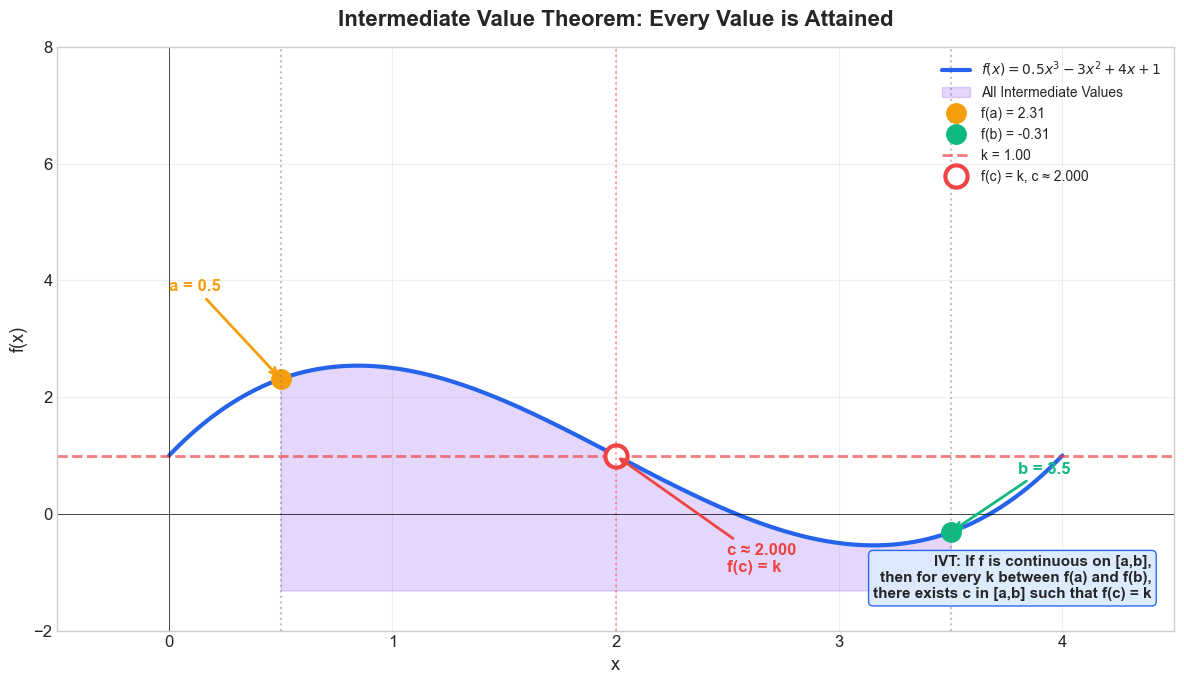

✅ Section 9 Complete: IVT verified with c ≈ 2.0000


In [11]:
# Section 9: Intermediate Value Theorem Visualization

fig, ax = plt.subplots(figsize=(12, 7))

x = np.linspace(0, 4, 500)
y = 0.5 * x**3 - 3 * x**2 + 4 * x + 1

a, b = 0.5, 3.5
fa = 0.5 * a**3 - 3 * a**2 + 4 * a + 1
fb = 0.5 * b**3 - 3 * b**2 + 4 * b + 1
k = (fa + fb) / 2  # Intermediate value

# Find c such that f(c) = k (numerically)
from scipy.optimize import brentq

def f_func(x):
    return 0.5 * x**3 - 3 * x**2 + 4 * x + 1 - k

c = brentq(f_func, a, b)

# Plot function
ax.plot(x, y, color='#2563EB', linewidth=3, label=r'$f(x) = 0.5x^3 - 3x^2 + 4x + 1$')

# Shade the region between a and b
x_shade = np.linspace(a, b, 200)
y_shade = 0.5 * x_shade**3 - 3 * x_shade**2 + 4 * x_shade + 1
ax.fill_between(x_shade, min(fa, fb) - 1, y_shade, alpha=0.2, color='#7C3AED', 
               label='All Intermediate Values')

# Mark a and b
ax.plot(a, fa, 'o', color='#F59E0B', markersize=14, label=f'f(a) = {fa:.2f}')
ax.plot(b, fb, 'o', color='#10B981', markersize=14, label=f'f(b) = {fb:.2f}')

# Mark intermediate value k
ax.axhline(k, color='#EF4444', linestyle='--', linewidth=2, alpha=0.7, label=f'k = {k:.2f}')
ax.plot(c, k, 'o', color='#EF4444', markersize=16, markerfacecolor='white', markeredgewidth=3,
        label=f'f(c) = k, c ≈ {c:.3f}')

# Vertical lines at a, b, c
ax.axvline(a, color='gray', linestyle=':', alpha=0.5)
ax.axvline(b, color='gray', linestyle=':', alpha=0.5)
ax.axvline(c, color='#EF4444', linestyle=':', alpha=0.5)

# Annotations
ax.annotate(f'a = {a}', xy=(a, fa), xytext=(a - 0.5, fa + 1.5),
            arrowprops=dict(arrowstyle='->', color='#F59E0B', lw=2),
            fontsize=12, color='#F59E0B', fontweight='bold')
ax.annotate(f'b = {b}', xy=(b, fb), xytext=(b + 0.3, fb + 1),
            arrowprops=dict(arrowstyle='->', color='#10B981', lw=2),
            fontsize=12, color='#10B981', fontweight='bold')
ax.annotate(f'c ≈ {c:.3f}\nf(c) = k', xy=(c, k), xytext=(c + 0.5, k - 2),
            arrowprops=dict(arrowstyle='->', color='#EF4444', lw=2),
            fontsize=12, color='#EF4444', fontweight='bold')

ax.set_title('Intermediate Value Theorem: Every Value is Attained', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-2, 8)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# IVT statement box
ax.text(0.98, 0.05, 
        'IVT: If f is continuous on [a,b],\n'
        'then for every k between f(a) and f(b),\n'
        'there exists c in [a,b] such that f(c) = k',
        transform=ax.transAxes, fontsize=11, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='#DBEAFE', edgecolor='#2563EB', alpha=0.95),
        fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✅ Section 9 Complete: IVT verified with c ≈ {c:.4f}")

# 10. Continuous vs Discontinuous Comparison

## Concept
A side-by-side comparison reveals the stark differences between continuous and discontinuous functions. Continuity enables prediction; discontinuity introduces unpredictability.

## Mathematical Definition

**Continuous:** $\lim_{x \to a} f(x) = f(a)$ for all $a$ in the domain.

**Discontinuous:** There exists at least one point $a$ where $\lim_{x \to a} f(x) \neq f(a)$ or the limit does not exist.

## Intuition
- **Continuous:** A smooth river flow — predictable, navigable.
- **Discontinuous:** A waterfall — sudden, unpredictable drop.

## Real World Example
- Continuous: Gradual temperature change throughout the day.
- Discontinuous: A digital thermostat switching between ON and OFF states.

## AI/ML Connection
- **Continuous models** (neural networks with smooth activations) allow gradient-based optimization.
- **Discontinuous models** (decision trees with hard splits) require different optimization strategies.

## Key Takeaway
> Continuity = smoothness = differentiability (usually) = gradient-based learning. Discontinuity requires alternative optimization or smoothing techniques.

<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\3744041462.py:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax1.plot(x_cont, y_cont, color='#059669', linewidth=3, label='Continuous: $f(x) = \sin(x) e^{-0.1x^2}$')
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\3744041462.py:60: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\3744041462.py:60: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
e:\Organization\ML-Vers

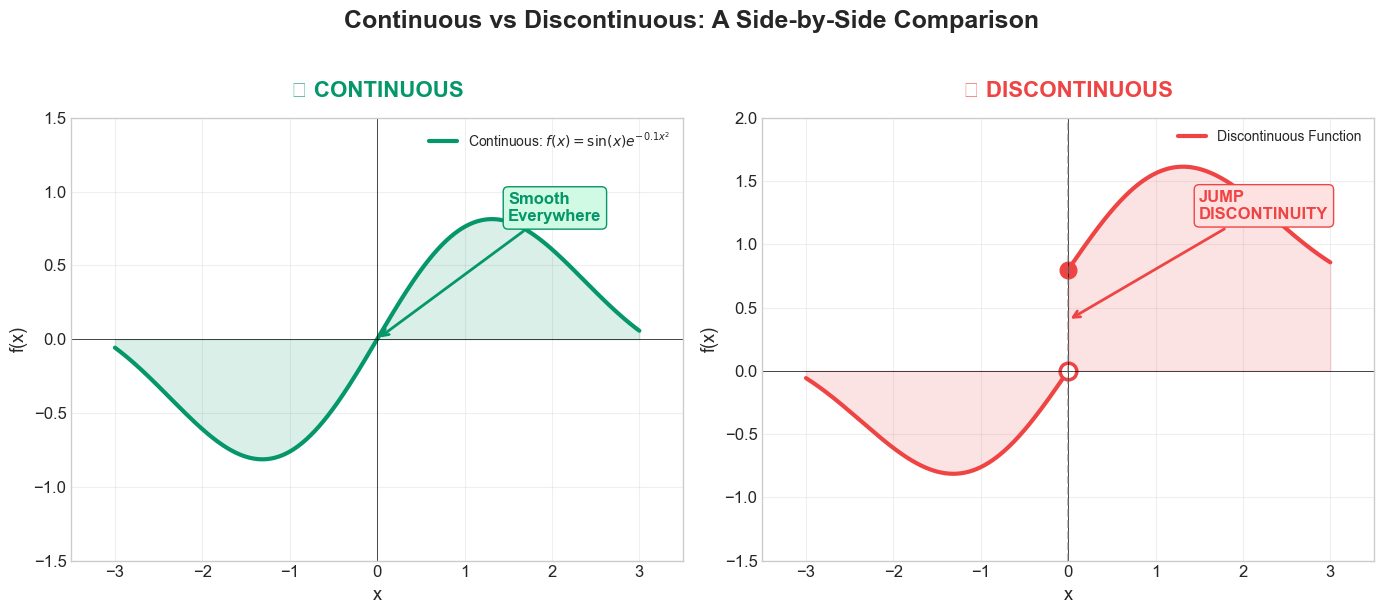

✅ Section 10 Complete: Side-by-side comparison of continuous vs discontinuous functions.


In [12]:
# Section 10: Side-by-Side Comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Continuous Function
x_cont = np.linspace(-3, 3, 500)
y_cont = np.sin(x_cont) * np.exp(-0.1 * x_cont**2)

ax1.plot(x_cont, y_cont, color='#059669', linewidth=3, label='Continuous: $f(x) = \sin(x) e^{-0.1x^2}$')
ax1.fill_between(x_cont, y_cont, alpha=0.15, color='#059669')
ax1.set_title('✅ CONTINUOUS', fontsize=16, fontweight='bold', color='#059669', pad=15)
ax1.set_xlabel('x', fontsize=13)
ax1.set_ylabel('f(x)', fontsize=13)
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-1.5, 1.5)
ax1.legend(loc='upper right', fontsize=10)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)

# Add smoothness indicators
ax1.annotate('Smooth\nEverywhere', xy=(0, 0), xytext=(1.5, 0.8),
             arrowprops=dict(arrowstyle='->', color='#059669', lw=2),
             fontsize=12, color='#059669', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#D1FAE5', edgecolor='#059669'))

# RIGHT: Discontinuous Function
x_disc_left = np.linspace(-3, -0.01, 200)
x_disc_right = np.linspace(0.01, 3, 200)
y_disc_left = np.sin(x_disc_left) * np.exp(-0.1 * x_disc_left**2)
y_disc_right = np.sin(x_disc_right) * np.exp(-0.1 * x_disc_right**2) + 0.8

ax2.plot(x_disc_left, y_disc_left, color='#EF4444', linewidth=3, label='Discontinuous Function')
ax2.plot(x_disc_right, y_disc_right, color='#EF4444', linewidth=3)
ax2.fill_between(x_disc_left, y_disc_left, alpha=0.15, color='#EF4444')
ax2.fill_between(x_disc_right, y_disc_right, alpha=0.15, color='#EF4444')

# Jump at x = 0
ax2.plot(0, 0, 'o', color='#EF4444', markersize=12, markerfacecolor='white', markeredgewidth=2.5)
ax2.plot(0, 0.8, 'o', color='#EF4444', markersize=12)

ax2.set_title('❌ DISCONTINUOUS', fontsize=16, fontweight='bold', color='#EF4444', pad=15)
ax2.set_xlabel('x', fontsize=13)
ax2.set_ylabel('f(x)', fontsize=13)
ax2.set_xlim(-3.5, 3.5)
ax2.set_ylim(-1.5, 2)
ax2.legend(loc='upper right', fontsize=10)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Add jump indicator
ax2.annotate('JUMP\nDISCONTINUITY', xy=(0, 0.4), xytext=(1.5, 1.2),
             arrowprops=dict(arrowstyle='->', color='#EF4444', lw=2),
             fontsize=12, color='#EF4444', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#FEE2E2', edgecolor='#EF4444'))

fig.suptitle('Continuous vs Discontinuous: A Side-by-Side Comparison', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("✅ Section 10 Complete: Side-by-side comparison of continuous vs discontinuous functions.")

# 11. Activation Functions in Deep Learning

## Concept
Activation functions introduce non-linearity into neural networks. Their **continuity properties** directly impact training stability and convergence.

## Mathematical Definitions

**Sigmoid:**
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
- **Continuous:** ✅ Everywhere
- **Smooth:** ✅ Differentiable everywhere
- **Range:** $(0, 1)$

**Tanh:**
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
- **Continuous:** ✅ Everywhere
- **Smooth:** ✅ Differentiable everywhere
- **Range:** $(-1, 1)$

**ReLU (Rectified Linear Unit):**
$$\text{ReLU}(x) = \max(0, x)$$
- **Continuous:** ✅ Everywhere
- **Smooth:** ❌ Not differentiable at $x = 0$ (kink/discontinuity in derivative)
- **Range:** $[0, \infty)$

**Softplus:**
$$\text{Softplus}(x) = \ln(1 + e^x)$$
- **Continuous:** ✅ Everywhere
- **Smooth:** ✅ Differentiable everywhere (smooth approximation to ReLU)
- **Range:** $(0, \infty)$

## Intuition
- **Sigmoid/Tanh:** Smooth ramps — gentle, continuous transitions.
- **ReLU:** A ramp with a sharp corner — continuous but not smooth at the origin.
- **Softplus:** A rounded ramp — smooth everywhere, approximating ReLU.

## Real World Example
- Sigmoid: Probability of rain (smooth transition from 0% to 100%).
- ReLU: A door that is either closed (0) or opens proportionally (linear).

## AI/ML Connection
- **ReLU's kink** at $x = 0$ causes "dying ReLU" problems but enables sparse activation.
- **Softplus** and **Swish** were developed to smooth ReLU while preserving its benefits.
- Continuity ensures gradients flow; smoothness ensures gradients are well-behaved.

## Key Takeaway
> Activation function choice balances continuity, smoothness, computational efficiency, and expressiveness. In modern deep learning, we prefer continuous (and usually smooth) activations.

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\3730603353.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\3730603353.py:80: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()


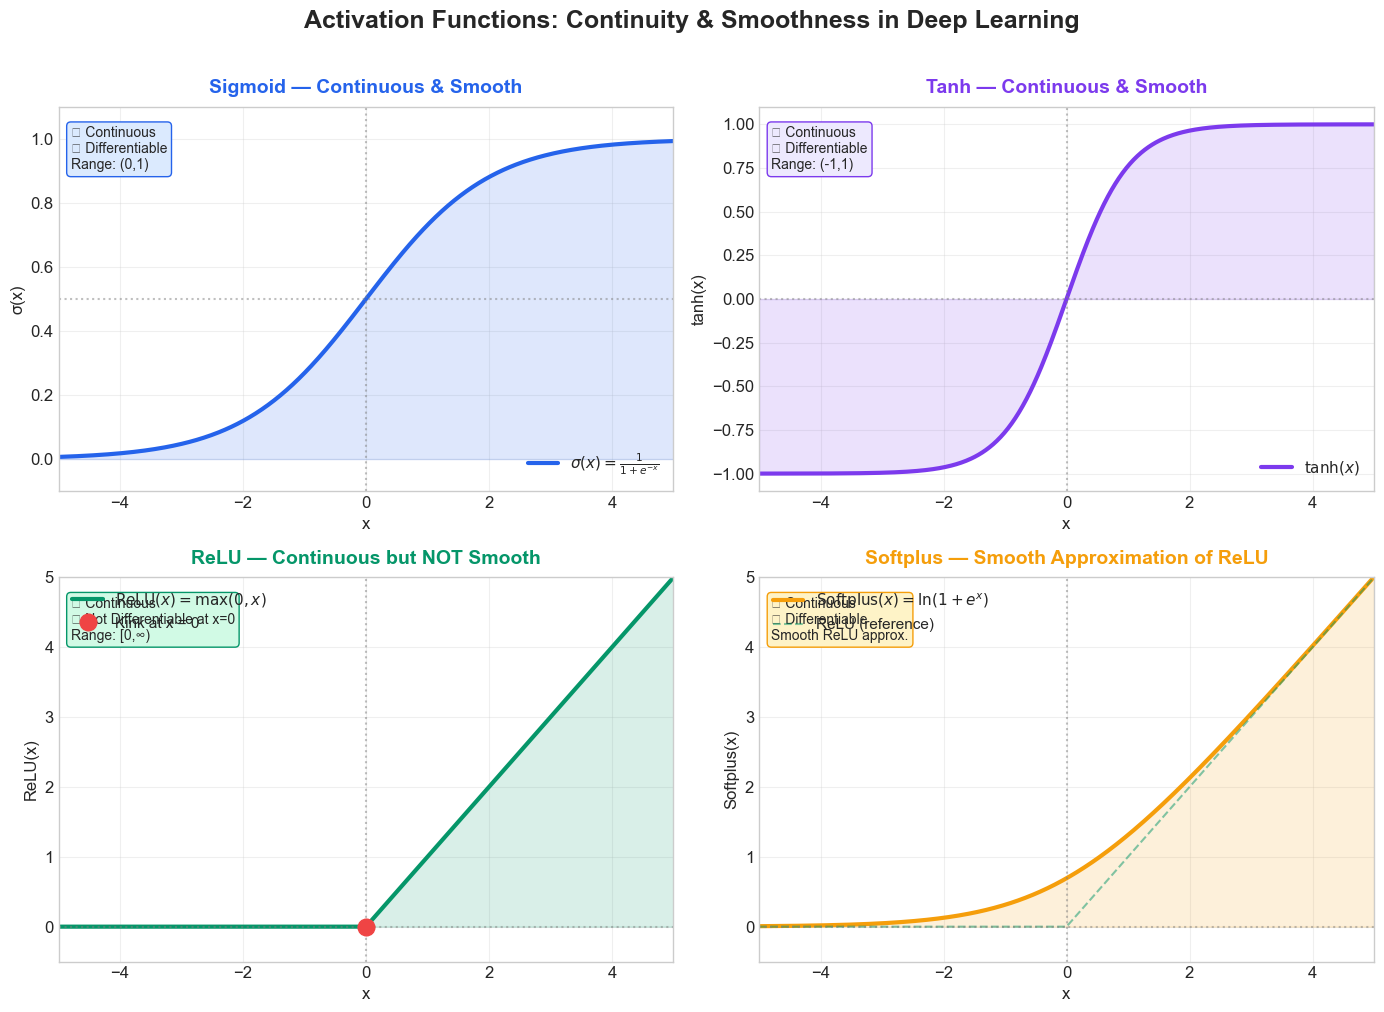

✅ Section 11 Complete: Activation functions with continuity analysis.


In [13]:
# Section 11: Activation Functions in Deep Learning

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.linspace(-5, 5, 500)

# Sigmoid
ax = axes[0, 0]
y_sig = 1 / (1 + np.exp(-x))
ax.plot(x, y_sig, color='#2563EB', linewidth=3, label=r'$\sigma(x) = \frac{1}{1+e^{-x}}$')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(x, 0, y_sig, alpha=0.15, color='#2563EB')
ax.set_title('Sigmoid — Continuous & Smooth', fontsize=14, fontweight='bold', color='#2563EB', pad=10)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('σ(x)', fontsize=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.1, 1.1)
ax.legend(loc='lower right', fontsize=11)
ax.text(0.02, 0.95, '✅ Continuous\n✅ Differentiable\nRange: (0,1)', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#DBEAFE', edgecolor='#2563EB'))

# Tanh
ax = axes[0, 1]
y_tanh = np.tanh(x)
ax.plot(x, y_tanh, color='#7C3AED', linewidth=3, label=r'$\tanh(x)$')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(x, 0, y_tanh, alpha=0.15, color='#7C3AED')
ax.set_title('Tanh — Continuous & Smooth', fontsize=14, fontweight='bold', color='#7C3AED', pad=10)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('tanh(x)', fontsize=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-1.1, 1.1)
ax.legend(loc='lower right', fontsize=11)
ax.text(0.02, 0.95, '✅ Continuous\n✅ Differentiable\nRange: (-1,1)', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#EDE9FE', edgecolor='#7C3AED'))

# ReLU
ax = axes[1, 0]
y_relu = np.maximum(0, x)
ax.plot(x, y_relu, color='#059669', linewidth=3, label=r'$\text{ReLU}(x) = \max(0,x)$')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(x, 0, y_relu, alpha=0.15, color='#059669')
ax.plot(0, 0, 'o', color='#EF4444', markersize=12, label='Kink at x = 0')
ax.set_title('ReLU — Continuous but NOT Smooth', fontsize=14, fontweight='bold', color='#059669', pad=10)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('ReLU(x)', fontsize=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5)
ax.legend(loc='upper left', fontsize=11)
ax.text(0.02, 0.95, '✅ Continuous\n❌ Not Differentiable at x=0\nRange: [0,∞)', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#D1FAE5', edgecolor='#059669'))

# Softplus
ax = axes[1, 1]
y_softplus = np.log(1 + np.exp(x))
ax.plot(x, y_softplus, color='#F59E0B', linewidth=3, label=r'$\text{Softplus}(x) = \ln(1+e^x)$')
ax.plot(x, y_relu, '--', color='#059669', linewidth=1.5, alpha=0.5, label='ReLU (reference)')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(x, 0, y_softplus, alpha=0.15, color='#F59E0B')
ax.set_title('Softplus — Smooth Approximation of ReLU', fontsize=14, fontweight='bold', color='#F59E0B', pad=10)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Softplus(x)', fontsize=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5)
ax.legend(loc='upper left', fontsize=11)
ax.text(0.02, 0.95, '✅ Continuous\n✅ Differentiable\nSmooth ReLU approx.', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#FEF3C7', edgecolor='#F59E0B'))

fig.suptitle('Activation Functions: Continuity & Smoothness in Deep Learning', 
             fontsize=18, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

print("✅ Section 11 Complete: Activation functions with continuity analysis.")

# 12. Optimization Landscape

## Concept
In machine learning, we minimize a **loss function** over model parameters. A **continuous, smooth** loss landscape allows gradient-based optimizers to find minima efficiently.

## Mathematical Definition

Consider the simple quadratic loss:

$$\text{Loss}(x) = (x - 3)^2$$

This is a **convex, continuous, smooth** function with a global minimum at $x = 3$.

For a 2D parameter space:
$$\text{Loss}(x, y) = (x - 3)^2 + (y - 2)^2$$

This forms a **smooth bowl-shaped surface** — the ideal optimization landscape.

## Intuition
A smooth valley is easy to walk down. A rocky, discontinuous terrain is hard to navigate. Gradient descent prefers smooth valleys.

## Real World Example
- A ball rolling down a smooth hill finds the bottom naturally.
- A ball on a staircase bounces unpredictably — discontinuous terrain.

## AI/ML Connection
- **Convex loss landscapes** (e.g., linear regression MSE) guarantee convergence to global minimum.
- **Non-convex landscapes** (e.g., deep neural networks) have many local minima, but continuity still allows gradient descent to find good solutions.
- **Discontinuities** in loss (e.g., from hard thresholding) break gradient flow.

## Key Takeaway
> A continuous loss landscape is the foundation of gradient-based learning. Smoothness accelerates convergence.

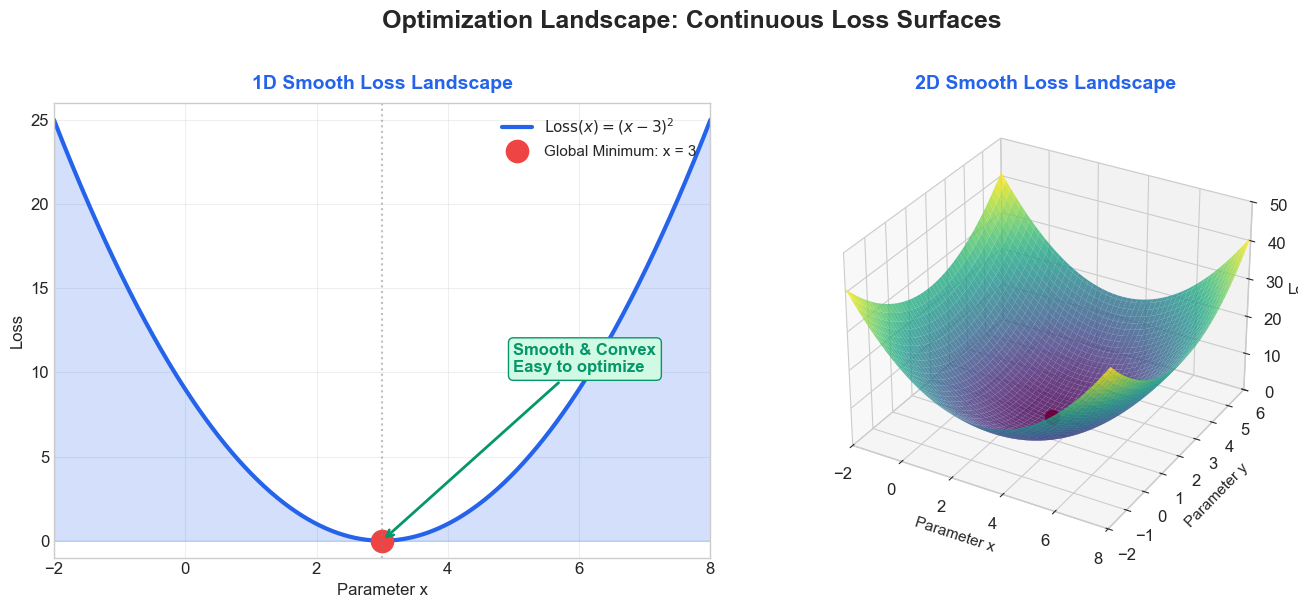

✅ Section 12 Complete: Smooth, continuous optimization landscape visualized.


In [14]:
# Section 12: Optimization Landscape

fig = plt.figure(figsize=(14, 6))

# 1D Loss Landscape
ax1 = fig.add_subplot(1, 2, 1)
x_1d = np.linspace(-2, 8, 500)
loss_1d = (x_1d - 3)**2

ax1.plot(x_1d, loss_1d, color='#2563EB', linewidth=3, label=r'$\text{Loss}(x) = (x - 3)^2$')
ax1.fill_between(x_1d, 0, loss_1d, alpha=0.2, color='#2563EB')
ax1.plot(3, 0, 'o', color='#EF4444', markersize=16, label='Global Minimum: x = 3')
ax1.axvline(3, color='gray', linestyle=':', alpha=0.5)

ax1.set_title('1D Smooth Loss Landscape', fontsize=14, fontweight='bold', color='#2563EB', pad=10)
ax1.set_xlabel('Parameter x', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xlim(-2, 8)
ax1.set_ylim(-1, 26)
ax1.legend(loc='upper right', fontsize=11)
ax1.annotate('Smooth & Convex\nEasy to optimize', xy=(3, 0), xytext=(5, 10),
             arrowprops=dict(arrowstyle='->', color='#059669', lw=2),
             fontsize=12, color='#059669', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#D1FAE5', edgecolor='#059669'))

# 2D Loss Landscape (Contour + Surface)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

X = np.linspace(-2, 8, 100)
Y = np.linspace(-2, 6, 100)
X, Y = np.meshgrid(X, Y)
Z = (X - 3)**2 + (Y - 2)**2

surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.scatter([3], [2], [0], color='red', s=100, label='Global Minimum')
ax2.set_title('2D Smooth Loss Landscape', fontsize=14, fontweight='bold', color='#2563EB', pad=10)
ax2.set_xlabel('Parameter x', fontsize=11)
ax2.set_ylabel('Parameter y', fontsize=11)
ax2.set_zlabel('Loss', fontsize=11)
ax2.set_xlim(-2, 8)
ax2.set_ylim(-2, 6)
ax2.set_zlim(0, 50)

fig.suptitle('Optimization Landscape: Continuous Loss Surfaces', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("✅ Section 12 Complete: Smooth, continuous optimization landscape visualized.")

# 13. Gradient Descent Animation

## Concept
**Gradient Descent** is the workhorse of deep learning. It iteratively moves parameters in the direction of steepest descent. A **continuous loss function** makes this possible.

## Mathematical Definition

For loss function $L(x)$, the update rule is:

$$x_{t+1} = x_t - \eta \cdot \nabla L(x_t)$$

Where $\eta$ is the **learning rate**.

For $L(x) = (x - 3)^2$:
$$\nabla L(x) = 2(x - 3)$$

## Intuition
A hiker with a compass always walks downhill. The compass (gradient) points in the direction of steepest descent. On a smooth, continuous hill, this always leads to the bottom.

## Real World Example
- Water flowing downhill follows the gradient of the terrain.
- A marble rolling in a bowl settles at the bottom.

## AI/ML Connection
- **Stochastic Gradient Descent (SGD)** uses mini-batch gradients to navigate high-dimensional, continuous loss landscapes.
- **Momentum, Adam, RMSprop** are advanced gradient descent variants that exploit continuity and smoothness.
- Without continuity, gradients are undefined and descent fails.

## Key Takeaway
> Gradient descent relies on continuity and differentiability. The smoother the landscape, the faster and more reliably we converge to optimal parameters.

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\4089689954.py:59: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\4089689954.py:59: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
e:\Organization\ML-Verse\mlverse-machine-learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Organization\ML-Verse\mlverse-machine-learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


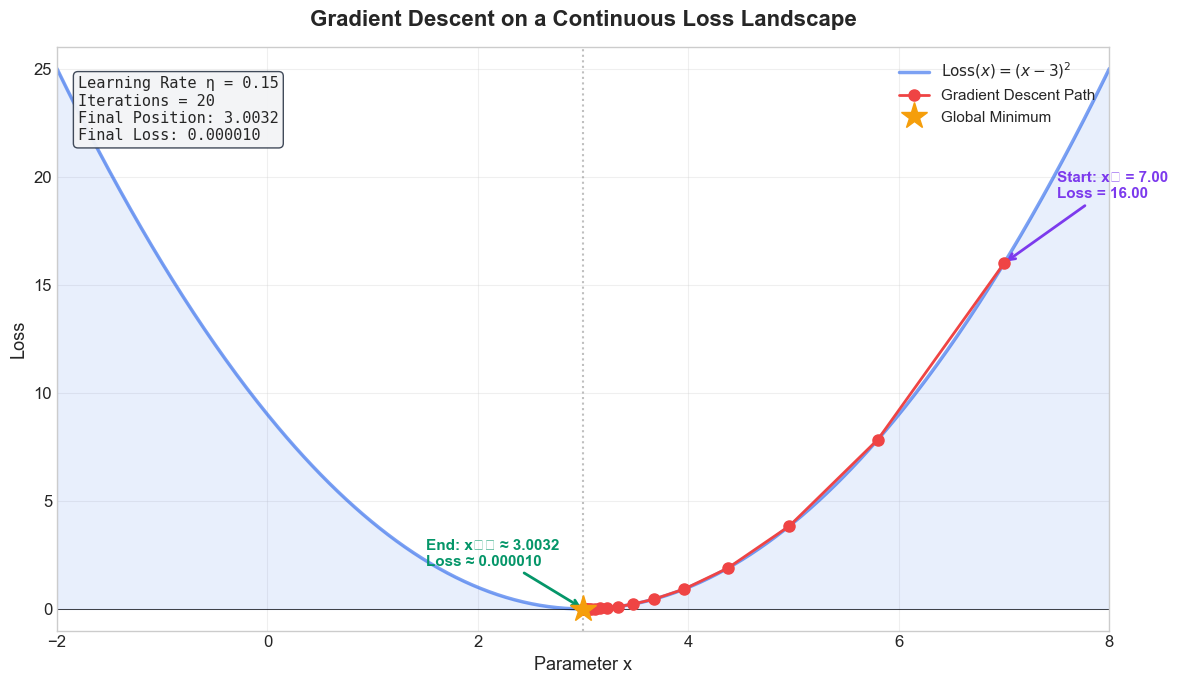

✅ Section 13 Complete: Gradient descent converges to minimum on continuous landscape.


In [15]:
# Section 13: Gradient Descent Animation

fig, ax = plt.subplots(figsize=(12, 7))

x = np.linspace(-2, 8, 500)
loss = (x - 3)**2

ax.plot(x, loss, color='#2563EB', linewidth=2.5, alpha=0.6, label=r'$\text{Loss}(x) = (x - 3)^2$')
ax.fill_between(x, 0, loss, alpha=0.1, color='#2563EB')

# Gradient descent trajectory
x_start = 7.0
learning_rate = 0.15
num_steps = 20

trajectory_x = [x_start]
trajectory_y = [(x_start - 3)**2]

for i in range(num_steps):
    grad = 2 * (trajectory_x[-1] - 3)
    new_x = trajectory_x[-1] - learning_rate * grad
    trajectory_x.append(new_x)
    trajectory_y.append((new_x - 3)**2)

# Plot trajectory
ax.plot(trajectory_x, trajectory_y, 'o-', color='#EF4444', markersize=8, linewidth=2, 
        label='Gradient Descent Path', zorder=5)
ax.plot(3, 0, '*', color='#F59E0B', markersize=20, label='Global Minimum', zorder=6)

# Annotate start and end
ax.annotate(f'Start: x₀ = {trajectory_x[0]:.2f}\nLoss = {trajectory_y[0]:.2f}', 
            xy=(trajectory_x[0], trajectory_y[0]), xytext=(trajectory_x[0] + 0.5, trajectory_y[0] + 3),
            arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=2),
            fontsize=11, color='#7C3AED', fontweight='bold')

ax.annotate(f'End: x₂₀ ≈ {trajectory_x[-1]:.4f}\nLoss ≈ {trajectory_y[-1]:.6f}', 
            xy=(trajectory_x[-1], trajectory_y[-1]), xytext=(trajectory_x[-1] - 1.5, trajectory_y[-1] + 2),
            arrowprops=dict(arrowstyle='->', color='#059669', lw=2),
            fontsize=11, color='#059669', fontweight='bold')

ax.set_title('Gradient Descent on a Continuous Loss Landscape', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Parameter x', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_xlim(-2, 8)
ax.set_ylim(-1, 26)
ax.legend(loc='upper right', fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(3, color='gray', linestyle=':', alpha=0.5)

# Info box
ax.text(0.02, 0.95,
        f'Learning Rate η = {learning_rate}\n'
        f'Iterations = {num_steps}\n'
        f'Final Position: {trajectory_x[-1]:.4f}\n'
        f'Final Loss: {trajectory_y[-1]:.6f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.95, edgecolor='#374151'))

plt.tight_layout()
plt.show()

print("✅ Section 13 Complete: Gradient descent converges to minimum on continuous landscape.")

# 14. Neural Network Learning Intuition

## Concept
Neural networks learn by navigating a high-dimensional **continuous loss landscape**. The continuity of this landscape ensures that small weight updates lead to predictable changes in loss.

## Mathematical Definition

For a neural network with weights $\mathbf{W}$ and loss $L(\mathbf{W})$:

$$\mathbf{W}_{t+1} = \mathbf{W}_t - \eta \nabla_{\mathbf{W}} L(\mathbf{W}_t)$$

The **backpropagation algorithm** computes gradients through the chain rule:

$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_i}$$

Each partial derivative requires the activation functions to be **continuous and differentiable**.

## Intuition
Imagine tuning the knobs on a complex machine. If the machine responds smoothly to each knob turn, you can find the optimal settings. If a knob causes a sudden jump, tuning becomes unpredictable.

## Real World Example
- Tuning a radio: small dial adjustments produce smooth sound changes (continuous).
- A broken volume knob that jumps from silent to loud (discontinuous).

## AI/ML Connection
- **Stable gradients** require continuous, smooth activations.
- **Vanishing gradients** (in deep networks with sigmoid) and **exploding gradients** are issues of gradient magnitude, not continuity.
- **Batch Normalization** and **Residual Connections** help maintain stable gradient flow through continuous paths.

## Key Takeaway
> Neural network learning is fundamentally a continuous optimization process. Continuity of loss and activations ensures that backpropagation can reliably guide weight updates toward better performance.

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_16156\2741106867.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


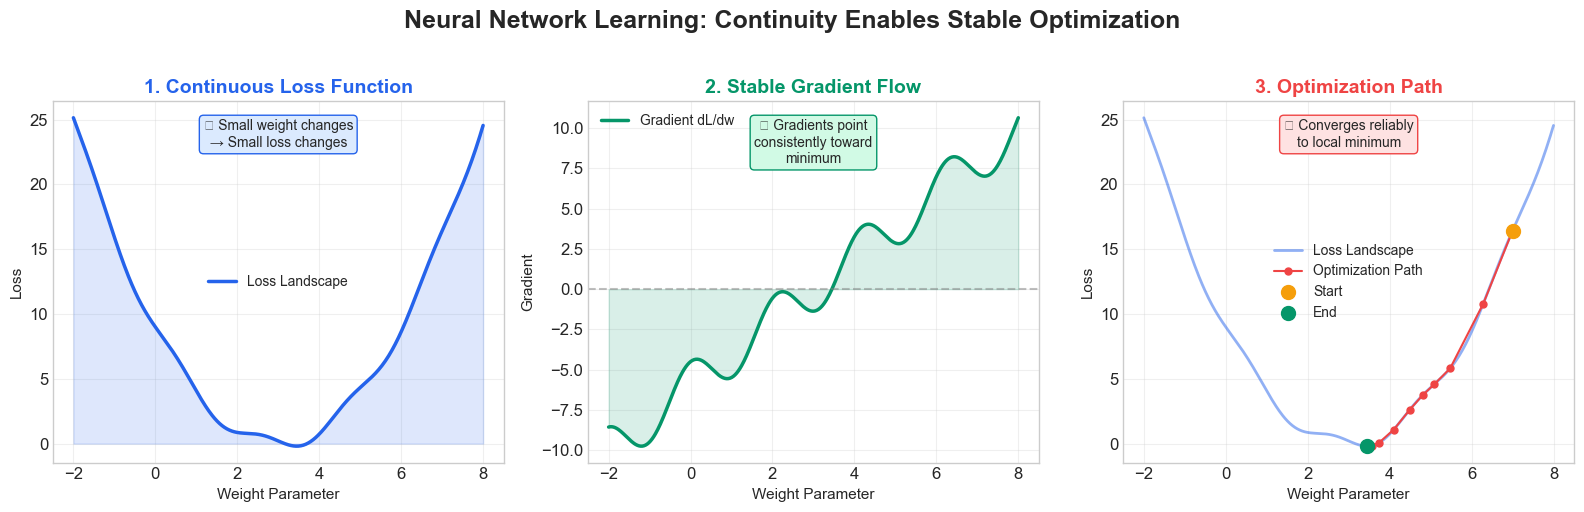

✅ Section 14 Complete: Neural network learning intuition with continuity.


In [16]:
# Section 14: Neural Network Learning Intuition

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Continuous Loss Function
x = np.linspace(-2, 8, 500)
loss = (x - 3)**2 + 0.5 * np.sin(3*x)  # Slightly wiggly but continuous
ax1.plot(x, loss, color='#2563EB', linewidth=2.5, label='Loss Landscape')
ax1.fill_between(x, 0, loss, alpha=0.15, color='#2563EB')
ax1.set_title('1. Continuous Loss Function', fontsize=14, fontweight='bold', color='#2563EB')
ax1.set_xlabel('Weight Parameter', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.legend(fontsize=10)
ax1.text(0.5, 0.95, '✅ Small weight changes\n→ Small loss changes', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#DBEAFE', edgecolor='#2563EB'))

# Plot 2: Stable Gradient Flow
x_grad = np.linspace(-2, 8, 500)
grad = 2*(x_grad - 3) + 1.5 * np.cos(3*x_grad)
ax2.plot(x_grad, grad, color='#059669', linewidth=2.5, label='Gradient dL/dw')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(x_grad, 0, grad, alpha=0.15, color='#059669')
ax2.set_title('2. Stable Gradient Flow', fontsize=14, fontweight='bold', color='#059669')
ax2.set_xlabel('Weight Parameter', fontsize=11)
ax2.set_ylabel('Gradient', fontsize=11)
ax2.legend(fontsize=10)
ax2.text(0.5, 0.95, '✅ Gradients point\nconsistently toward\nminimum', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#D1FAE5', edgecolor='#059669'))

# Plot 3: Optimization Path
ax3.plot(x, loss, color='#2563EB', linewidth=2, alpha=0.5, label='Loss Landscape')
# Simulate optimization path
path_x = [7.0]
path_y = [(path_x[0] - 3)**2 + 0.5 * np.sin(3*path_x[0])]
for _ in range(30):
    grad = 2*(path_x[-1] - 3) + 1.5 * np.cos(3*path_x[-1])
    new_x = path_x[-1] - 0.1 * grad
    path_x.append(new_x)
    path_y.append((new_x - 3)**2 + 0.5 * np.sin(3*new_x))

ax3.plot(path_x, path_y, 'o-', color='#EF4444', markersize=5, linewidth=1.5, label='Optimization Path')
ax3.plot(path_x[0], path_y[0], 'o', color='#F59E0B', markersize=10, label='Start')
ax3.plot(path_x[-1], path_y[-1], 'o', color='#059669', markersize=10, label='End')
ax3.set_title('3. Optimization Path', fontsize=14, fontweight='bold', color='#EF4444')
ax3.set_xlabel('Weight Parameter', fontsize=11)
ax3.set_ylabel('Loss', fontsize=11)
ax3.legend(fontsize=10)
ax3.text(0.5, 0.95, '✅ Converges reliably\nto local minimum', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#FEE2E2', edgecolor='#EF4444'))

fig.suptitle('Neural Network Learning: Continuity Enables Stable Optimization', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("✅ Section 14 Complete: Neural network learning intuition with continuity.")

# Summary

## What We Learned

### 1. Continuity
A function $f(x)$ is **continuous at $x = a$** if:
$$\lim_{x \to a} f(x) = f(a)$$

This means:
- The function is defined at $a$
- The limit exists
- The limit equals the function value

### 2. Types of Discontinuity
| Type | Description | Example | Fixable? |
|------|-------------|---------|----------|
| **Removable** | Hole in graph | $\frac{x^2-1}{x-1}$ at $x=1$ | ✅ Yes |
| **Jump** | Left ≠ Right limit | Step function | ❌ No |
| **Infinite** | Function → ±∞ | $\frac{1}{x}$ at $x=0$ | ❌ No |
| **Oscillatory** | Infinite oscillations | $\sin(\frac{1}{x})$ at $x=0$ | ❌ No |

### 3. Importance in Calculus
- **Intermediate Value Theorem** guarantees completeness.
- **Differentiability** requires continuity.
- **Integration** is well-defined for continuous functions.

### 4. Importance in Optimization
- Gradient descent requires **continuous, differentiable** loss functions.
- Discontinuities create **unpredictable jumps** in loss.
- Smooth landscapes enable **reliable convergence**.

### 5. Importance in Deep Learning
- **Activation functions** must be continuous for stable training.
- **Backpropagation** relies on the chain rule, which requires differentiability.
- **BatchNorm, ResNets** preserve gradient flow through continuous paths.
- Modern architectures (Transformers, CNNs) use smooth, continuous operations.

### 6. Importance in Gradient Descent
- Continuity ensures **small steps → small changes**.
- Smoothness ensures **gradients point consistently** toward minima.
- Without continuity, optimizers get stuck or oscillate wildly.

---

> **Final Thought:** Continuity is the silent foundation of modern machine learning. Every neural network training session, every gradient update, every prediction relies on the mathematical guarantee that small changes in input produce small, predictable changes in output. Understanding continuity is understanding why deep learning works.

---

*Notebook created for MLVerse Education Cloud — 03_Continuity*